## Problem 2

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [2]:
train_data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW2/BreastCancer_train.csv')
test_data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW2/BreastCancer_test.csv')

In [3]:
train_data = train_data.dropna()
test_data = test_data.dropna()

In [4]:
y_train = train_data['Class'].map({'benign':1, 'malignant':0})
X_train = train_data.drop(columns='Class')
X_train = sm.add_constant(X_train) # Add a constant term to the predictor

In [5]:
y_test = test_data['Class'].map({'benign':1, 'malignant':0})
X_test = test_data.drop(columns='Class')
X_test = sm.add_constant(X_test)

## Problem 2-1

In [6]:
LR = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.068072
         Iterations 10


In [7]:
print(LR.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  392
Model:                          Logit   Df Residuals:                      381
Method:                           MLE   Df Model:                           10
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                  0.8945
Time:                        17:47:15   Log-Likelihood:                -26.684
converged:                       True   LL-Null:                       -253.05
Covariance Type:            nonrobust   LLR p-value:                 5.471e-91
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.9222      1.988      4.991      0.000       6.026      13.818
Id               7.554e-07   1.26e-06      0.600      0.548   -1.71e-06    3.22e-06
Cl.thickness       -0.3681      

### We have used all the predictors to fit a logistic regression model and report the summary.

In [8]:
y_predict = LR.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

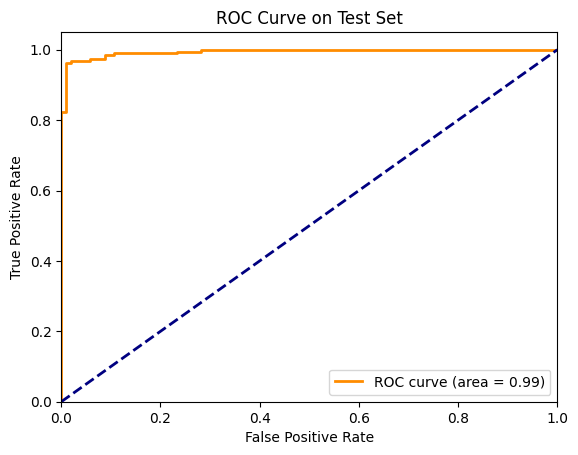

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_predict)
roc_auc_LR_full = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_LR_full)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

### We have ploted the ROC curve on the test dataset.

## Problem 2-2

In [11]:
predictors_select = train_data[['Cl.thickness', 'Cell.shape', 'Marg.adhesion', 'Bare.nuclei', 'Bl.cromatin']]

In [12]:
LR_selected = sm.Logit(y_train,predictors_select ).fit()

Optimization terminated successfully.
         Current function value: 0.494432
         Iterations 7


In [13]:
print(LR_selected.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  392
Model:                          Logit   Df Residuals:                      387
Method:                           MLE   Df Model:                            4
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                  0.2341
Time:                        17:47:15   Log-Likelihood:                -193.82
converged:                       True   LL-Null:                       -253.05
Covariance Type:            nonrobust   LLR p-value:                 1.138e-24
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Cl.thickness      0.4623      0.069      6.734      0.000       0.328       0.597
Cell.shape       -0.5371      0.095     -5.654      0.000      -0.723      -0.351
Marg.adhesion    -0.1553      0.077     

In [14]:
y_predict_selected = LR.predict(X_test)

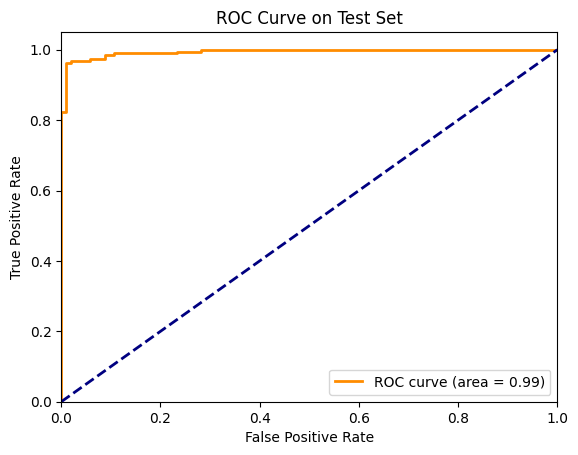

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_predict_selected)
roc_auc_LR_smaller = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_LR_smaller)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

### After selecting the predictors, we have fitted the model, reported the summary and plotted the ROC

## Problem 2-3

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [17]:
# LDA does not have summary like statismodels, so we could use confusion matrix as summary
lda_train = lda.predict(X_train)

print(confusion_matrix(y_train, lda_train))

[[128   8]
 [  6 250]]


### We have used all the predictors to fit an LDA model and reported the summary

In [18]:
y_lda_predict = lda.predict(X_test)

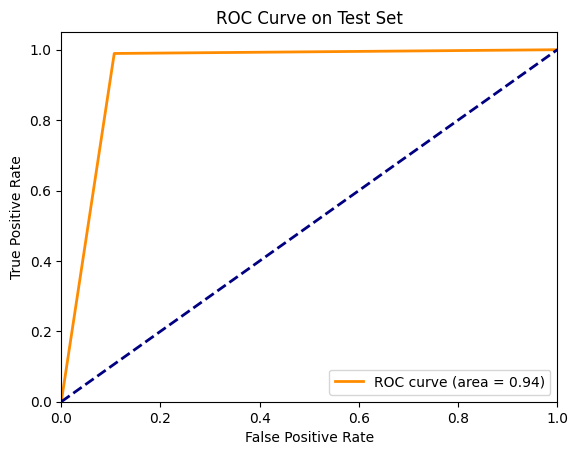

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_lda_predict)
roc_auc_LDA_full = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_LDA_full)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

### We have plotted the ROC curve on the test dataset in LDA.

## Problem 2-4

In [20]:
X_selected_LDA = X_train[['Cl.thickness','Cell.shape','Marg.adhesion','Bare.nuclei','Bl.cromatin']]

In [21]:
lda.fit(X_selected_LDA, y_train)

lda_selected_train = lda.predict(X_selected_LDA)

print(confusion_matrix(y_train, lda_selected_train))

[[125  11]
 [  5 251]]


### We have used the predictors [Cl.thickness, Cell.shape, Marg.adhesion, Bare.nuclei, Bl.cromatin] to fit an LDA model and reported the summary.

In [22]:
X_selected_test = X_test[['Cl.thickness','Cell.shape','Marg.adhesion','Bare.nuclei','Bl.cromatin']]
y_lda_selected_predict = lda.predict(X_selected_test)

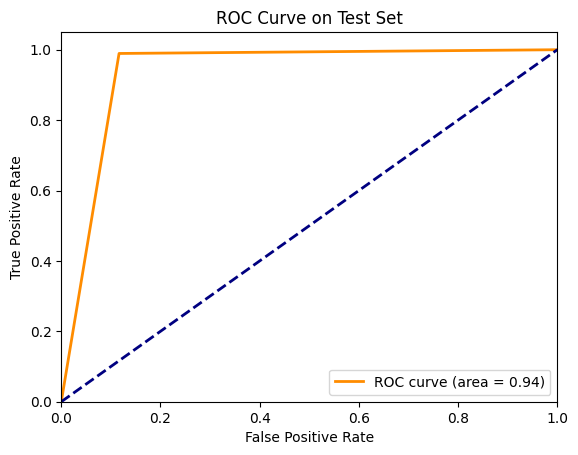

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_lda_selected_predict)
roc_auc_LDA_smaller = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_LDA_smaller)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

### We have plotted the ROC curve on the test dataset.

## Problem 2-5

In [24]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

roc = QuadraticDiscriminantAnalysis()

y_train = train_data['Class'].map({'benign':1, 'malignant':0})
X_train = train_data.drop(columns='Class')

roc.fit(X_train, y_train)

y_train_predict = roc.predict(X_train)
print(confusion_matrix(y_train, y_train_predict))

[[134   2]
 [ 13 243]]


### We have used all the predictors to fit a QDA model and reported the summary.

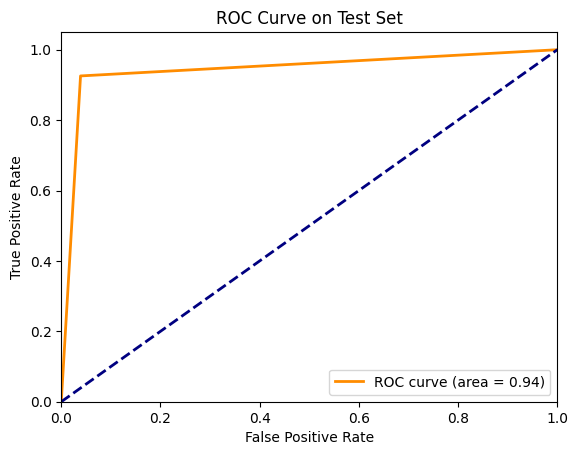

In [25]:
y_test = test_data['Class'].map({'benign':1, 'malignant':0})
X_test = test_data.drop(columns='Class')

y_pred = roc.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc_QDA = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_QDA)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

### We have plotted the ROC curve on the test dataset.

## Problem 2-6

### Based on the AUC, we compare all the above models.

In [26]:
print(f"Logistic Regression (all predictors): AUC = {roc_auc_LR_full:.3f}")
print(f"Logistic Regression (selected predictors): AUC = {roc_auc_LR_smaller:.3f}")
print(f"LDA (all predictors): AUC = {roc_auc_LDA_full:.3f}")
print(f"LDA (selected predictors): AUC = {roc_auc_LDA_smaller:.3f}")
print(f"QDA (all predictors): AUC = {roc_auc_QDA:.3f}")

Logistic Regression (all predictors): AUC = 0.994
Logistic Regression (selected predictors): AUC = 0.994
LDA (all predictors): AUC = 0.941
LDA (selected predictors): AUC = 0.936
QDA (all predictors): AUC = 0.943


## Problem 3

In [27]:
data_3 = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW2/cars.csv')

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline

In [29]:
data_3 = data_3.dropna()

In [30]:
X = data_3[['speed']]
y = data_3['dist']

## Problem 3-1

Degree 1 :LOO_MSE = 246.4054
Degree 2 :LOO_MSE = 243.0292
Degree 3 :LOO_MSE = 246.8288
Degree 4 :LOO_MSE = 250.0914
Degree 5 :LOO_MSE = 279.6864
Degree 6 :LOO_MSE = 327.5014
Degree 7 :LOO_MSE = 408.9481
Degree 8 :LOO_MSE = 476.2207
Degree 9 :LOO_MSE = 456.0527
Degree 10 :LOO_MSE = 406.1928


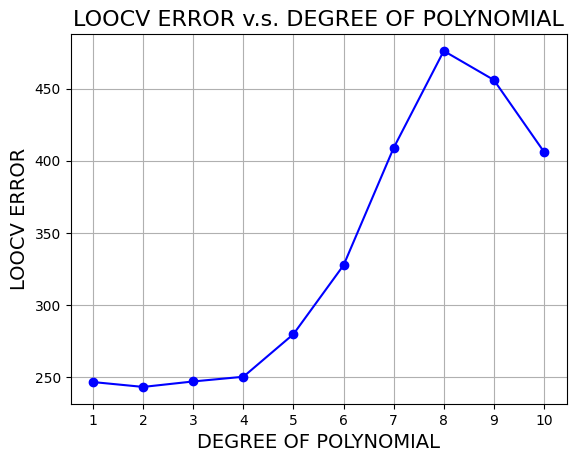

In [31]:
loo = LeaveOneOut()

degrees = range(1, 11)
cv_errors_poly = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(model, X, y, cv = loo, scoring = 'neg_mean_squared_error')
    avg_mse = -scores.mean()
    cv_errors_poly.append(avg_mse)
    print(f"Degree {degree} :LOO_MSE = {avg_mse:.4f}")
    
plt.figure()
plt.plot(degrees, cv_errors_poly, marker = 'o',linestyle = '-', color = 'b')
plt.title('LOOCV ERROR v.s. DEGREE OF POLYNOMIAL',fontsize = 16)
plt.xlabel('DEGREE OF POLYNOMIAL',fontsize = 14)
plt.ylabel('LOOCV ERROR',fontsize = 14)
plt.xticks(degrees)
plt.grid(True)
plt.show()

### According the LOOCV-plot, we can choose degree = 2 as the polynomial model parameter.

## Problem 3-2

Degree 1 :5-CV_MSE = 265.8523
Degree 2 :5-CV_MSE = 304.5630
Degree 3 :5-CV_MSE = 1879.4172
Degree 4 :5-CV_MSE = 3532.1265
Degree 5 :5-CV_MSE = 23519.1800
Degree 6 :5-CV_MSE = 520279.1559
Degree 7 :5-CV_MSE = 56410050.3495
Degree 8 :5-CV_MSE = 5875146.7085
Degree 9 :5-CV_MSE = 546726877.1205
Degree 10 :5-CV_MSE = 1298927074.1552


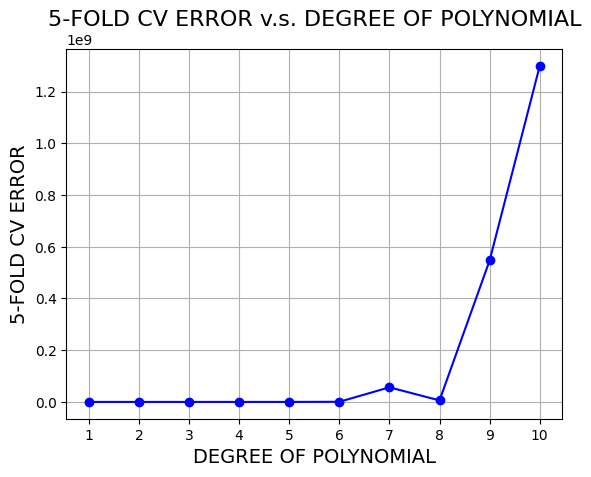

In [32]:
degrees = range(1, 11)
cv_errors_poly = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(model, X, y, cv = 5,scoring = 'neg_mean_squared_error')
    avg_mse = -scores.mean()
    cv_errors_poly.append(avg_mse)
    print(f"Degree {degree} :5-CV_MSE = {avg_mse:.4f}")
    
plt.figure()
plt.plot(degrees, cv_errors_poly, marker = 'o',linestyle = '-', color = 'b')
plt.title('5-FOLD CV ERROR v.s. DEGREE OF POLYNOMIAL',fontsize = 16)
plt.xlabel('DEGREE OF POLYNOMIAL',fontsize = 14)
plt.ylabel('5-FOLD CV ERROR',fontsize = 14)
plt.xticks(degrees)
plt.grid(True)
plt.show()

### According the 5-folds CV-plot, we can choose degree = 1 as the polynomial model parameter.

## Problem 3-3

Bandwidth 1 :LOOCV_MSE = 250.2211
Bandwidth 2 :LOOCV_MSE = 244.9927
Bandwidth 3 :LOOCV_MSE = 254.8921
Bandwidth 4 :LOOCV_MSE = 263.4869
Bandwidth 5 :LOOCV_MSE = 268.7843
Bandwidth 6 :LOOCV_MSE = 272.0281
Bandwidth 7 :LOOCV_MSE = 274.1063
Bandwidth 8 :LOOCV_MSE = 275.5030
Bandwidth 9 :LOOCV_MSE = 276.4820
Bandwidth 10 :LOOCV_MSE = 277.1926


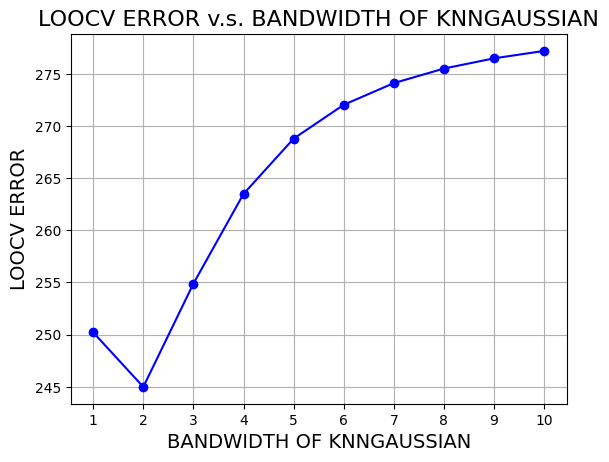

In [33]:
from sklearn.neighbors import KNeighborsRegressor

def gaussian_kernel_smoothing(distance, bandwidth):
    return np.exp(-0.5 * (distance / bandwidth) ** 2)



loo = LeaveOneOut()

bandwidths = range(1, 11)
cv_errors_knng = []

for bandwidth in bandwidths:
    model = KNeighborsRegressor(n_neighbors = 10, weights = lambda d: gaussian_kernel_smoothing(d,bandwidth))
    scores = cross_val_score(model, X, y, cv = loo, scoring = 'neg_mean_squared_error')
    avg_mse = -scores.mean()
    cv_errors_knng.append(avg_mse)
    print(f"Bandwidth {bandwidth} :LOOCV_MSE = {avg_mse:.4f}")
    
plt.figure()
plt.plot(bandwidths, cv_errors_knng, marker = 'o',linestyle = '-', color = 'b')
plt.title('LOOCV ERROR v.s. BANDWIDTH OF KNNGAUSSIAN',fontsize = 16)
plt.xlabel('BANDWIDTH OF KNNGAUSSIAN',fontsize = 14)
plt.ylabel('LOOCV ERROR',fontsize = 14)
plt.xticks(bandwidths)
plt.grid(True)
plt.show()

### Based on LOOCV method, we should choose bandwidth = 2.

Bandwidth 1 :5-CV_MSE = 620.6065
Bandwidth 2 :5-CV_MSE = 518.7023
Bandwidth 3 :5-CV_MSE = 472.0541
Bandwidth 4 :5-CV_MSE = 457.4079
Bandwidth 5 :5-CV_MSE = 451.6622
Bandwidth 6 :5-CV_MSE = 448.8878
Bandwidth 7 :5-CV_MSE = 447.3431
Bandwidth 8 :5-CV_MSE = 446.3941
Bandwidth 9 :5-CV_MSE = 445.7684
Bandwidth 10 :5-CV_MSE = 445.3334


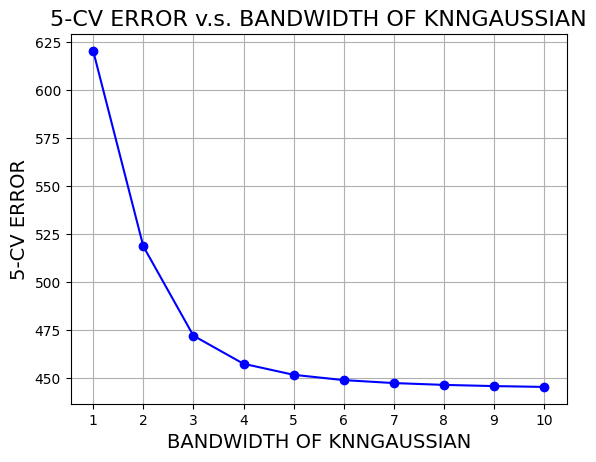

In [34]:
from sklearn.neighbors import KNeighborsRegressor

def gaussian_kernel_smoothing(distance, bandwidth):
    return np.exp(-0.5 * (distance / bandwidth) ** 2)



bandwidths = range(1, 11)
cv_errors_knng = []

for h in bandwidths:
    model = KNeighborsRegressor(
        n_neighbors=10,
        weights=lambda d, bw=h: gaussian_kernel_smoothing(d, bw)
    )
    scores = cross_val_score(model, X, y, cv = 5,scoring = 'neg_mean_squared_error')
    avg_mse = -scores.mean()
    cv_errors_knng.append(avg_mse)
    print(f"Bandwidth {h} :5-CV_MSE = {avg_mse:.4f}")
    
plt.figure()
plt.plot(bandwidths, cv_errors_knng, marker = 'o',linestyle = '-', color = 'b')
plt.title('5-CV ERROR v.s. BANDWIDTH OF KNNGAUSSIAN',fontsize = 16)
plt.xlabel('BANDWIDTH OF KNNGAUSSIAN',fontsize = 14)
plt.ylabel('5-CV ERROR',fontsize = 14)
plt.xticks(bandwidths)
plt.grid(True)
plt.show()

### Based on LOOCV method, we should choose bandwidth = 4.

## Problem 3-4

###  · Based on the LOOCV results, the polynomial regression with degree = 2 with LOO MSE = 243.03 performs better than the KNN–Gaussian kernel model with bandwidth = 2 with LOO MSE = 244.99.
### · Under the 5-fold cross-validation, the polynomial regression with degree = 1 achieves the lowest MSE 265.8 and clearly outperforms the KNN–Gaussian model with best MSE 445.

## Problem 4

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [36]:
data_4 = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW2/titanic.csv')
data_4 = data_4.drop(columns='Cabin')
data_4 = data_4.dropna()
data_4

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [37]:
data_4['Pclass']
# we find the type of Pclass is int64, we shouled seperate the 1 2 3, so we convert the type of Pclass

data_4['Pclass'] = data_4['Pclass'].astype('category')

In [38]:
# because we should report the estimated coefficients for Sex/male and pclass/3rd, therefore we use get_dummies 
X = pd.get_dummies(data_4[['Pclass','Sex','Age','SibSp','Fare']],drop_first = True)

X = sm.add_constant(X)

X = X.astype(int)

y = data_4['Survived']

X

,const,Age,SibSp,Fare,Pclass_2,Pclass_3,Sex_male
0,1,22,1,7,0,1,1
1,1,38,1,71,0,0,0
2,1,26,0,7,0,1,0
3,1,35,1,53,0,0,0
4,1,35,0,8,0,1,1
...,...,...,...,...,...,...,...
885,1,39,0,29,0,1,0
886,1,27,0,13,1,0,1
887,1,19,0,30,0,0,0
889,1,26,0,30,0,0,1


In [39]:
logitmodel = sm.Logit(y,X).fit()
print(logitmodel.summary())

Optimization terminated successfully.
         Current function value: 0.446245
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      705
Method:                           MLE   Df Model:                            6
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                  0.3387
Time:                        17:47:17   Log-Likelihood:                -317.73
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 2.861e-67
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1643      0.501      8.308      0.000       3.182       5.147
Age           -0.0443      0.

## Problem 4-1

In [40]:
coe_sexmale = logitmodel.params['Sex_male']
coe_pclass3 = logitmodel.params['Pclass_3']

conf_int_sexmale = logitmodel.conf_int().loc['Sex_male']
conf_int_pclass3 = logitmodel.conf_int().loc['Pclass_3']

In [41]:
print(f"the estimated coefficients for Sex/male is {coe_sexmale}, 95% confidence intervals is ({conf_int_sexmale[0]:.4f},{conf_int_sexmale[1]:.4f}).") 
print(f"the estimated coefficients for pclass/3rd is {coe_pclass3}, 95% confidence intervals is ({conf_int_pclass3[0]:.4f},{conf_int_pclass3[1]:.4f}).") 

the estimated coefficients for Sex/male is -2.6081823852970647, 95% confidence intervals is (-3.0309,-2.1855).
the estimated coefficients for pclass/3rd is -2.5197227240258817, 95% confidence intervals is (-3.1756,-1.8639).


### We have reported the estimated coefficients for Sex/male and pclass/3rd, and report their 95% confidence intervals.

## Problem 4-2

In [42]:
from sklearn.utils import resample

n_bootstraps = 1000
bootstrap_coefs = []

# because we should report the estimated coefficients for Sex/male and pclass/3rd, therefore we use get_dummies 
X = pd.get_dummies(data_4[['Pclass','Sex','Age','SibSp','Fare']],drop_first = True)

X = sm.add_constant(X)

X = X.astype(float)

y = data_4['Survived']

fail_count = 0

np.random.seed(5054244)

for i in range(n_bootstraps):
    bootstrap_sample = resample(data_4, replace = True, n_samples = len(data_4))
    X_bootstrap = pd.get_dummies(bootstrap_sample[['Pclass','Sex','Age','SibSp','Fare']], drop_first = True)
    
    X_bootstrap = sm.add_constant(X_bootstrap)
    X_bootstrap = X_bootstrap.astype(float)
    y_bootstrap = bootstrap_sample['Survived']
    
    X_bootstrap = X_bootstrap.reindex(columns=X.columns, fill_value=0)
    
    
    try:
        bootslogitmodel = sm.Logit(y_bootstrap, X_bootstrap).fit(disp=0)
        bootstrap_coefs.append(bootslogitmodel.params[['Sex_male', 'Pclass_3']])
    except np.linalg.LinAlgError:
        fail_count += 1
        continue
    

    
bootstrap_coefs_df = pd.DataFrame(bootstrap_coefs)

ci_bootstrap = bootstrap_coefs_df.quantile([0.025, 0.975])
    

In [43]:
ci_bootstrap

,Sex_male,Pclass_3
0.025,-3.054985,-3.300805
0.975,-2.259527,-1.933020


### The 95% confidence intervals obtained from Bootstrap are generally wider than those from the original model. This phenomenon reflect greater uncertainty estimated from resampling. 

## Problem 4-3

In [44]:
data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW2/titanic.csv')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [45]:
print(data.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [46]:
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


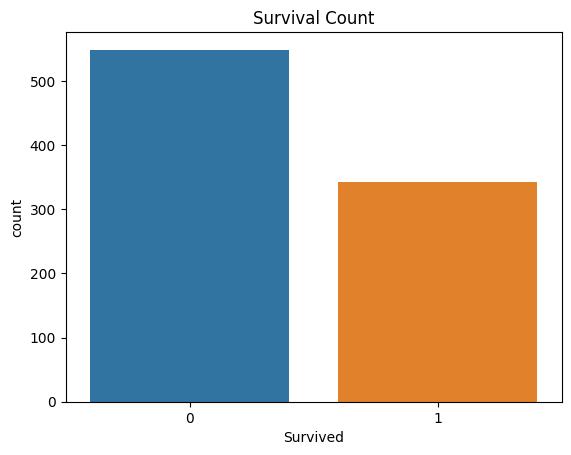

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=data)
plt.title('Survival Count')
plt.show()

print(data['Survived'].value_counts(normalize=True)) 

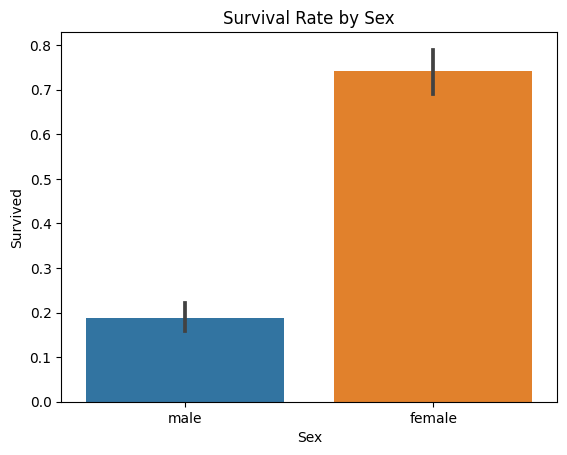

In [48]:
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Survival Rate by Sex')
plt.show()

### We can find：
* The overall survival rate is approximately 38%
* The number of deaths is greater than the number of survivors
* The survival rate of women is significantly higher than that of men, reflecting the "women and children first" policy

## Problem 4-4

In [49]:
test_point = data_4.iloc[[0]]
train_data = data_4.iloc[1:]

In [50]:
X_train = pd.get_dummies(train_data[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
X_train = sm.add_constant(X_train)
X_train = X_train.astype(float)
y_train = train_data['Survived']


X_test = pd.get_dummies(test_point[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.astype(float)



logit_model = sm.Logit(y_train, X_train).fit()
pred_prob = logit_model.predict(X_test)

print(f"Predicted survival probability for test point: {pred_prob.iloc[0]:.4f}")

Optimization terminated successfully.
         Current function value: 0.446778
         Iterations 6
Predicted survival probability for test point: 0.0204


In [51]:
n_bootstraps = 1000
bootstrap_probs = []

for i in range(n_bootstraps):
    bootstrap_sample = resample(train_data, replace=True, n_samples=len(train_data))
    
    X_boot = pd.get_dummies(bootstrap_sample[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
    X_boot = sm.add_constant(X_boot)
    X_boot = X_boot.reindex(columns=X_train.columns, fill_value=0)
    X_boot = X_boot.astype(float)
    y_boot = bootstrap_sample['Survived']
    
    try:
        boot_model = sm.Logit(y_boot, X_boot).fit(disp=0, maxiter=100)
        prob = boot_model.predict(X_test).iloc[0]
        bootstrap_probs.append(prob)
    except np.linalg.LinAlgError:
        fail_count += 1
        continue



95% Confidence Interval at test point:
Lower Bound: 0.0072
Upper Bound: 0.0482


/Users/mengchuishuo/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


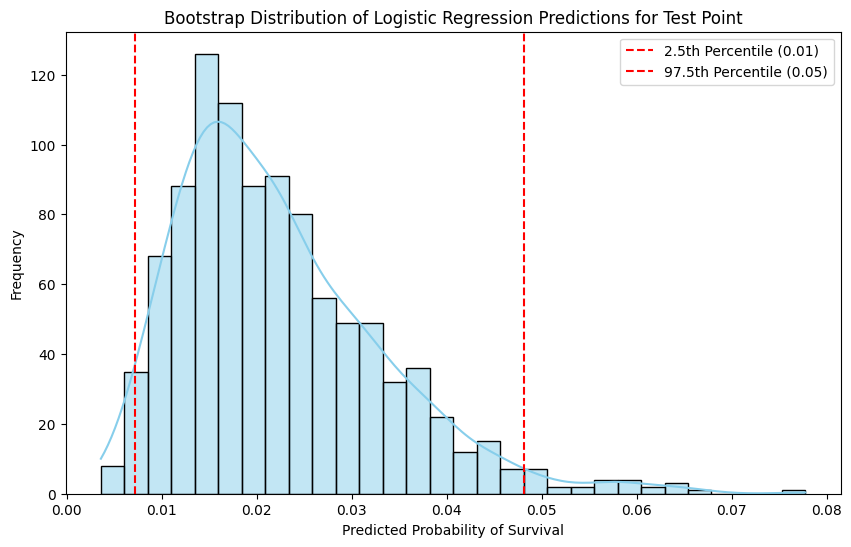

In [52]:
bootstrap_preds = np.array(bootstrap_probs).flatten()  


lower_bound = np.percentile(bootstrap_preds, 2.5)
upper_bound = np.percentile(bootstrap_preds, 97.5)
confidence_interval = (lower_bound, upper_bound)

print(f"95% Confidence Interval at test point:")
print(f"Lower Bound: {lower_bound:.4f}")
print(f"Upper Bound: {upper_bound:.4f}")


plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_preds, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.axvline(lower_bound, color='red', linestyle='--', label=f'2.5th Percentile ({lower_bound:.2f})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'97.5th Percentile ({upper_bound:.2f})')
plt.title(f'Bootstrap Distribution of Logistic Regression Predictions for Test Point')
plt.xlabel('Predicted Probability of Survival')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Problem 4-5

In [53]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

test_point = data_4.iloc[[0]]
train_data = data_4.iloc[1:]

X_train = pd.get_dummies(train_data[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
X_train = X_train.astype(float)
y_train = train_data['Survived']

X_test = pd.get_dummies(test_point[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.astype(float)

qda_model = QDA()
qda_model.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [54]:
pred_prob = qda_model.predict_proba(X_test)

In [55]:
pred_prob

array([[0.63698412, 0.36301588]])

### We can find the probability of this person's survival is much lower than that of death. So the survived predicted is 0.

In [56]:
n_bootstraps = 1000
bootstrap_probs = []
fail_count = 0

for i in range(n_bootstraps):
    bootstrap_sample = resample(train_data, replace=True, n_samples=len(train_data))
    
    X_boot = pd.get_dummies(bootstrap_sample[['Pclass','Sex','Age','SibSp','Fare']], drop_first=True)
    X_boot = X_boot.reindex(columns=X_train.columns, fill_value=0)
    X_boot = X_boot.astype(float)
    y_boot = bootstrap_sample['Survived']
    
    
    if len(np.unique(y_boot)) < 2:
        fail_count += 1
        continue
    
    try:
        boot_model = QDA()
        boot_model.fit(X_boot, y_boot)
        prob = boot_model.predict_proba(X_test)[0, 1]
        bootstrap_probs.append(prob)
    except Exception:
        fail_count += 1
        continue

In [57]:
bootstrap_probs = pd.DataFrame(bootstrap_probs)
pred_interval = bootstrap_probs.quantile([0.025, 0.975])


lower = pred_interval.iloc[0, 0]
upper = pred_interval.iloc[1, 0]

print(f"Bootstrap 95% prediction interval: ({lower:.4f}, {upper:.4f})")

Bootstrap 95% prediction interval: (0.1932, 0.6005)


/Users/mengchuishuo/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


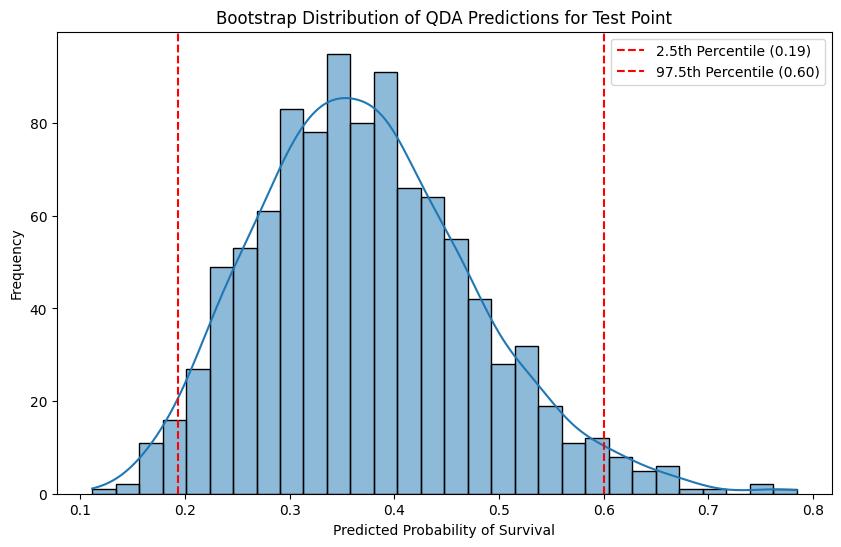

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_probs, bins=30, kde=True, color='skyblue', edgecolor='black')


plt.axvline(lower, color='red', linestyle='--', label=f'2.5th Percentile ({lower:.2f})')
plt.axvline(upper, color='red', linestyle='--', label=f'97.5th Percentile ({upper:.2f})')

plt.title('Bootstrap Distribution of QDA Predictions for Test Point')
plt.xlabel('Predicted Probability of Survival')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### According to Bootstrap distribution, we can find survival rate greater than 0.5 accounts for a small proportion.